# 2D Overdamped model - Dialanine

In this tutorial we are going to infer Langevin model on simulation data of dialanine in vaccum showcasing the analysis of 2D model.
The data are in the dialanine_trajectories.npz and contain 5 trajectories of equilibrium simulation of the dialanine in vaccum with Gromacs. Files contain the values of the $\phi, \psi$ dihedrals angles.

In [1]:
import numpy as np
import folie as fl

data = fl.Trajectories(dt=0.2) # Timestep is 0.2 ps
trjs = np.load("dialanine_trajectories.npz")  # Values in radians, convert evrything into degree

# Convert to degree
# Offset to center the plot
phi_offset = 60
psi_offset = -90
for arr in trjs.values():
    phi_dat = (((np.rad2deg(arr[:, 0]) + 180) + phi_offset) % 360) - 180
    psi_dat = (((np.rad2deg(arr[:, 1]) + 180) + psi_offset) % 360) - 180
    data.append(np.column_stack([phi_dat, psi_dat]))

print(data)  # Let's check what we have

/home/vroylan241/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.
Trajectory of length 100001 and dimension 2.



Let's look at the Ramachandran plot of the trajectories

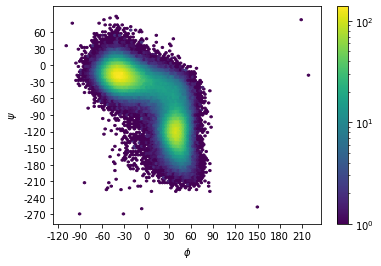

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from folie.data._data_statistics import hexbin

# Use histogram with hexbin for density plot
x_c, y_c, C, extent = hexbin(data, gridsize=360)
plt.hexbin(x_c, y_c, C=C, extent=extent, norm=LogNorm())
plt.colorbar()
phi_s, phi_e = -180 + phi_offset, 180 + phi_offset
psi_s, psi_e = -180 + psi_offset, 180 + psi_offset
plt.xticks(np.arange(-180, 180, 30), np.arange(phi_s, phi_e, 30))
plt.yticks(np.arange(-180, 180, 30), np.arange(psi_s, psi_e, 30))
plt.xlabel("$\phi$")
plt.ylabel("$\psi$")
plt.show()

Let's use a complex spatial variation by using finite element basis.

In [3]:
import skfem
import folie as fl

data.fit_density(method="hist", gridsize=360)  # Compute the density of points in space
# Create domain directly from Trajectories object (no concatenated array needed)
domain = fl.MeshedDomain.create_from_trajectories(data, method='density', bins=30, Ninit_vertices=125, N_min=50, min_scale=0.2)
mesh = domain.mesh



count =  0 N =  306 displacement =  6.771200966372317
count =  200 N =  306 displacement =  0.0993387168132121


Text(0, 0.5, '$\\psi$')

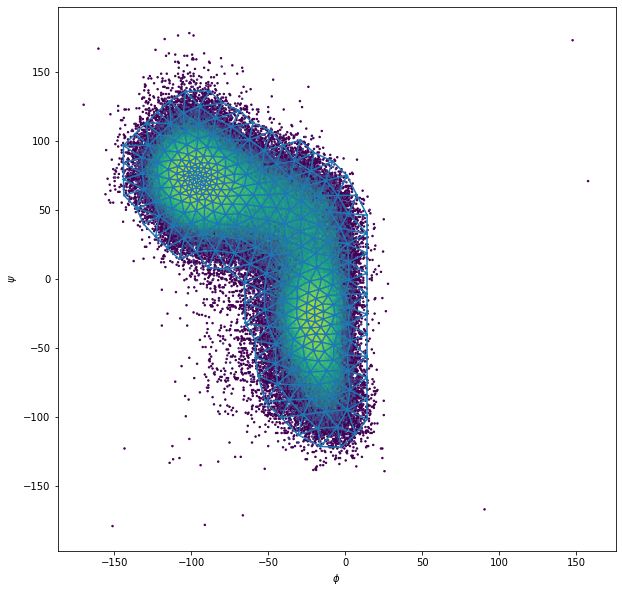

In [4]:
from skfem.visuals.matplotlib import draw, plot
# Plot the obtained mesh against the density of points in the space
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.hexbin(x_c, y_c, C=C, extent=extent, gridsize=360, norm=LogNorm())
# draw(mesh, ax=ax, linewidth=1.0)
ax.triplot(mesh.p[0,:], mesh.p[ 1,:], mesh.t.T)
ax.set_xlabel("$\phi$")
ax.set_ylabel("$\psi$")
# plt.show()

In [5]:
# Now run the estimation
from sklearn import linear_model
fun = fl.functions.FiniteElement(domain=domain, element=skfem.ElementTriP2())
model = fl.models.Overdamped(fun, dim=2)
estimator = fl.KramersMoyalEstimator(model)
model = estimator.fit_fetch(data,density_weighting="hist") #,estimator=linear_model.Ridge(alpha=1e-1, copy_X=False, fit_intercept=False)) # We use a Ridge regression for smoothing the estimation

We can then plot the force and diffusion profile

(306, 2)


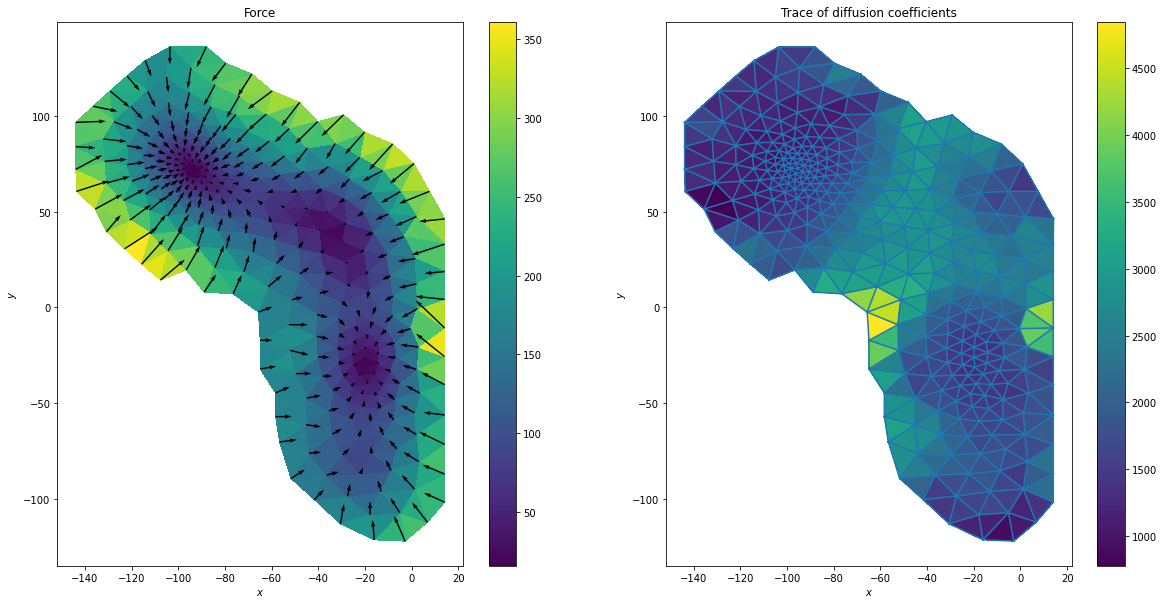

In [6]:
pts=mesh.p.T # Get points from the domain mesh for evaluation of the profile
tri = mesh.t.T

forces = model.pos_drift(pts)
print(forces.shape)
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Force plot
ax[0].set_title("Force")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
ax[0].grid()
force_mag = np.linalg.norm(forces, axis=1)
cset0 = ax[0].tripcolor(pts[:, 0], pts[:, 1], force_mag, triangles=tri)
ax[0].quiver(pts[:, 0], pts[:, 1], forces[:, 0], forces[:, 1])
fig.colorbar(cset0, ax=ax[0])

# Diffusion plot
ax[1].set_title("Trace of diffusion coefficients")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$y$")
diff = model.diffusion(pts)
diff_mag = np.linalg.trace(diff)
cset1 = ax[1].tripcolor(pts[:, 0], pts[:, 1], diff_mag, triangles=tri)
ax[1].triplot(pts[:, 0], pts[:, 1], tri)
fig.colorbar(cset1, ax=ax[1])
plt.show()

But also obtain the free energy profile

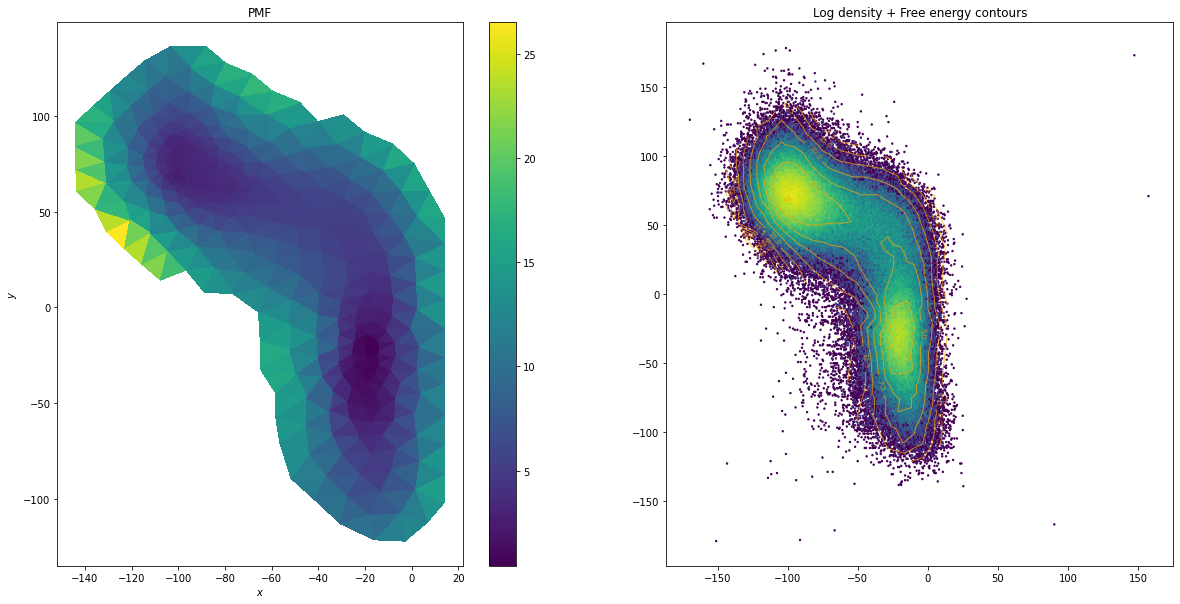

In [7]:
fem = fl.analysis.FreeEnergyAnalysis(model, domain, element=skfem.ElementTriP2(), weight_func=data.compute_density)
Vpmf = fem.free_energy_profile(alpha=0.0).evaluate(x=pts)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
# PMF plot
ax[0].set_title("PMF")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
cset0 = ax[0].tripcolor(pts[:, 0], pts[:, 1], Vpmf - np.min(Vpmf), triangles=tri)
fig.colorbar(cset0, ax=ax[0])
# To compare, plot the log density using histogram
ax[1].hexbin(x_c, y_c, C=C, extent=extent, gridsize=360, norm=LogNorm())
contour = ax[1].tricontour(pts[:, 0], pts[:, 1], tri, Vpmf - np.min(Vpmf), levels=15, colors='orange', alpha=0.7, linewidths=1.0)
ax[1].clabel(contour, inline=True, fontsize=7, fmt='%1.1f')
ax[1].set_title('Log density + Free energy contours')
plt.show()



### Rate analysis
The next step is to compute the rate to pass from one state to the other one. From the free energy profile, we can find the two local minima of the free energy and define the metastable states. We can then compute the mean first passage time between two metastable states directly from the trajectories.

State 1: PMF minimum at (-99.59, 76.60), F = -22.88
State 2: PMF minimum at (-20.80, -33.02), F = -24.83


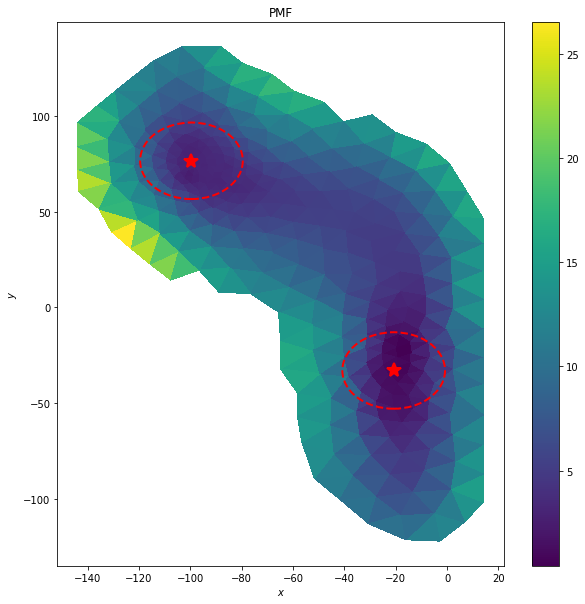

In [8]:
# Find the 2 minima of the free energy profile (PMF) using FEM basis directly
initial_centers = [np.array([-100.0, 75.0]), np.array([-25.0, -30.0])]
state_minima = fem.find_minima(initial_centers, method='Nelder-Mead', options={'xatol': 0.1, 'fatol': 0.01, 'maxiter': 1000})

state1_center, state1_val = state_minima[0]
state2_center, state2_val = state_minima[1]
print(f"State 1: PMF minimum at ({state1_center[0]:.2f}, {state1_center[1]:.2f}), F = {state1_val:.2f}")
print(f"State 2: PMF minimum at ({state2_center[0]:.2f}, {state2_center[1]:.2f}), F = {state2_val:.2f}")


state_radius = 20.0

from matplotlib.patches import Circle
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# PMF plot
ax.set_title("PMF")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
cset0 = ax.tripcolor(pts[:, 0], pts[:, 1], Vpmf - np.min(Vpmf), triangles=tri)
fig.colorbar(cset0, ax=ax)
# Mark the two PMF minima with circles on the PMF plot
for center, val in state_minima:
    circle = Circle(center, state_radius, color="red", fill=False, linewidth=2, linestyle="--")
    ax.add_patch(circle)
    ax.plot(center[0], center[1], "r*", markersize=15, markeredgewidth=2)


In [9]:
# Define the two metastable states as indicator functions
# Note: skfem passes x with shape (dim, N), so we need to handle that
def in_state1(x):
    """Check if point x is in state 1 (metastable basin 1)."""
    # Handle both (N, dim) and (dim, N) shapes
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[0] < x.shape[1]:  # (dim, N) shape
        x = x.T
    return np.linalg.norm(x - state1_center, axis=1) < state_radius

def in_state2(x):
    """Check if point x is in state 2 (metastable basin 2)."""
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[0] < x.shape[1]:  # (dim, N) shape
        x = x.T
    return np.linalg.norm(x - state2_center, axis=1) < state_radius


# Compute MFPT from trajectories
result = fl.data.mfpt_from_trajectories(data, in_state1, in_state2)

print(f"Mean first passage time (state 1 -> state 2): {result['mfpt_1_to_2']:.2f} ps ({result['n_transitions_1_to_2']} transitions)")
print(f"Mean first passage time (state 2 -> state 1): {result['mfpt_2_to_1']:.2f} ps ({result['n_transitions_2_to_1']} transitions)")
print(f"Estimated rate (1 -> 2): {result['rates'].get('1_to_2', 'N/A')}/ps")
print(f"Estimated rate (2 -> 1): {result['rates'].get('2_to_1', 'N/A')}/ps")

Mean first passage time (state 1 -> state 2): 9.78 ps (6279 transitions)
Mean first passage time (state 2 -> state 1): 6.14 ps (6281 transitions)
Estimated rate (1 -> 2): 0.1022758369059564/ps
Estimated rate (2 -> 1): 0.16281215816186342/ps


The rate to pass from one state to the other one can be computed using FEM.

Computed MFPT (state 1 -> state 2):  11.403159314815198  ps
Computed MFPT (state 2 -> state 1):  11.778064558291916  ps


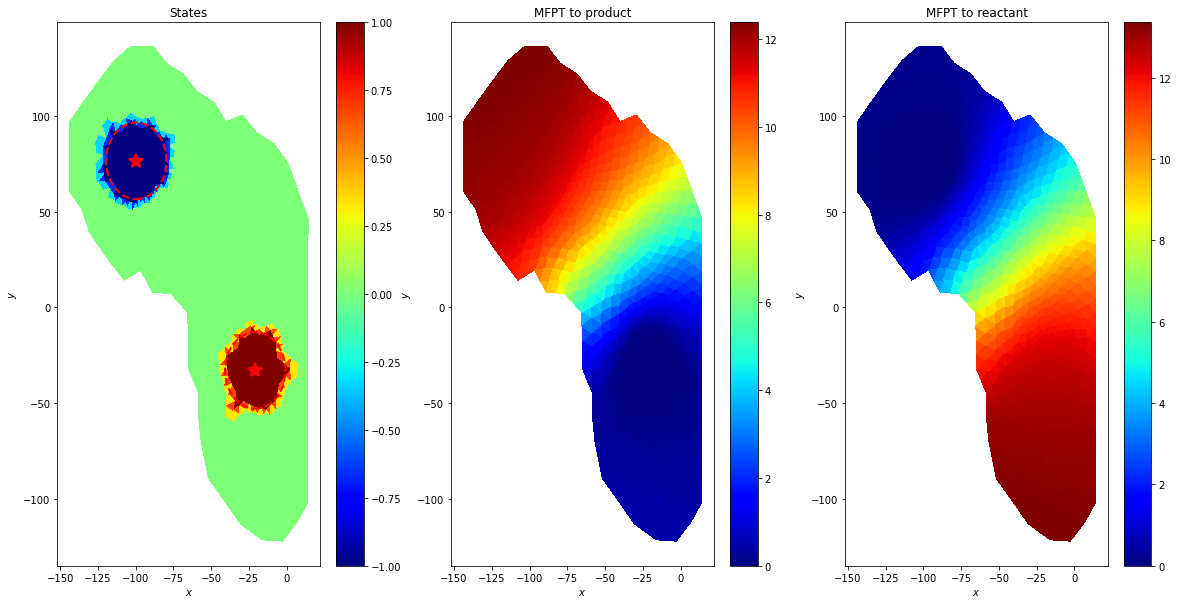

In [10]:
# Set the two states as subdomains of the mesh
mesh_rate = mesh  # .refined(2)
mesh_rate = mesh_rate.with_subdomains({"reactant": lambda x: in_state1(x)})
mesh_rate = mesh_rate.with_subdomains({"product": lambda x: in_state2(x)})

# Use RateAnalysis for MFPT computation
rate_fem = fl.analysis.RateAnalysis(model, domain, element=skfem.ElementTriP2())
mfpt_result = rate_fem.mfpt(mesh=mesh_rate, bc="elements")

pts_rate = mesh_rate.p.T
tri_rate = mesh_rate.t.T
print("Computed MFPT (state 1 -> state 2): ", mfpt_result.mfpt["reactant_to_product"]," ps")
print("Computed MFPT (state 2 -> state 1): ",mfpt_result.mfpt["product_to_reactant"]," ps")

mfpt_result.mfpt["product_to_reactant"]
# Plot results using scikit-fem native plotting
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

# States plot (use tripcolor with triangles for elemental data)
ax[0].set_title("States")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
plot(rate_fem.basis, mfpt_result.states, ax=ax[0], colorbar=True)
# cset0 = ax[0].tripcolor(pts_rate[:, 0], pts_rate[:, 1], mfpt_result.states, triangles=tri_rate)
# fig.colorbar(cset0, ax=ax[0])
# Add the two circles
for center, val in state_minima:
    circle = Circle(center, state_radius, color="red", fill=False, linewidth=2, linestyle="--")
    ax[0].add_patch(circle)
    ax[0].plot(center[0], center[1], "r*", markersize=15, markeredgewidth=2)


# MFPT to product
ax[1].set_title("MFPT to product")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$y$")

plot(rate_fem.basis, mfpt_result.to_product, ax=ax[1], colorbar=True)


# MFPT to reactant
ax[2].set_title("MFPT to reactant")
ax[2].set_xlabel("$x$")
ax[2].set_ylabel("$y$")
plot(rate_fem.basis, mfpt_result.to_reactant, ax=ax[2], colorbar=True)
plt.show()

The transition rate can also be obtained from the eigenvalues decomposition of the generator.

Eigenvalues [ 1.20119726e-15+0.j -1.83384116e-01+0.j -1.90291675e+00+0.j]
Spectral ratio 10.37667155644587
Eigenvalues [ 0.         -0.19078864]
Reduced matrix:
[[-0.09340094  0.09340094]
 [ 0.0973877  -0.0973877 ]]


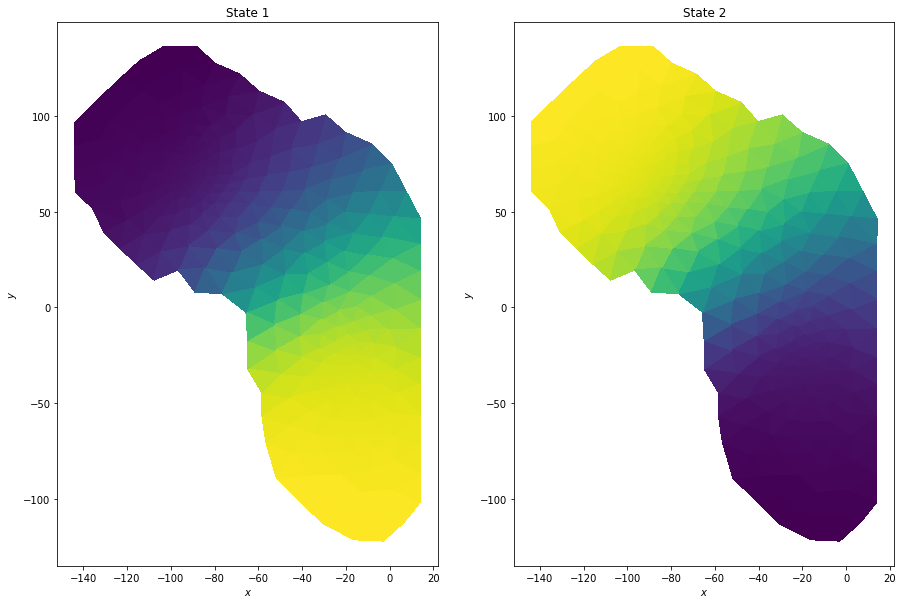

In [11]:
# Use the new RateAnalysis helper for eigenvalue-based rates
rates_result = rate_fem.transition_rates(n_states=2)

print(f"Eigenvalues {rates_result.eigenvalues}")
print(f"Reduced matrix:\n{rates_result.reduced_matrix}")

fig, ax = plt.subplots(1, 2, figsize=(15, 10))
# State 1 plot
ax[0].set_title("State 1")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y$")
cset0 = ax[0].tripcolor(pts[:, 0], pts[:, 1], rate_fem.basis.probes(pts.T) @ rates_result.memberships[:, 0], triangles=tri)

# State 2 plot
ax[1].set_title("State 2")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$y$")
cset1 = ax[1].tripcolor(pts[:, 0], pts[:, 1], rate_fem.basis.probes(pts.T) @ rates_result.memberships[:, 1], triangles=tri)
plt.show()